# Домашнее задание № 1

Вам необходимо провести анализ и подготовить данные.

# Исходные данные

Ознакомьтесь с данными в [источнике](https://www.kaggle.com/uciml/student-alcohol-consumption?select=student-por.csv):

Если вкратце, то у вас есть 29 параметров и одна целевая переменная G3.

In [106]:
import pandas as pd

In [107]:
# Читаем данные

X_train = pd.read_csv('train_features_with_answers.csv')

In [108]:
# Про характеристики прочитайте в источнике

X_train.head(5)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G3
0,MS,M,NaN,U,LE3,T,1,3,at_home,services,...,yes,yes,4,3,3,2,3,3,0,9
1,GP,M,NaN,R,LE3,T,3,3,teacher,other,...,yes,no,3,3,4,3,5,3,16,12
2,GP,M,15.0,NaN,GT3,T,3,4,other,other,...,yes,no,5,5,1,1,1,5,0,13
3,MS,M,17.0,R,GT3,T,4,3,services,other,...,yes,yes,4,5,5,1,3,2,4,11
4,GP,F,20.0,R,GT3,T,2,1,other,other,...,yes,yes,1,2,3,1,2,2,8,12


# Часть 1. Визуальный анализ данных (Exploratory Data Analysis)

Перед тем, как приступать к построению алгоритмов, необходимо понять данные, с которыми требуется работать. Для этого в подходах к построению алгоритмов машинного обучения выделят специальный этап - Разведочный анализ данных или Exploratory Data Analysis (EDA). EDA в себя включает все те, что касается описания данных: визуализацию, интерпретацию и анализ.

Прежде всего сделаем визуализацию данных для того, чтобы оценить диапазоны значений и виды их распределений.

Постройте для приведенных ниже характеристик следующие виды графиков:
- Гистограммы;
- Круговые диаграмм;
- Графики;
- Таблицы;
- 3D диаграммы.

Выберите наиболее подходящий тип графика для каждой характеристки.

__Основной критерий оценивания__ - читаемость и интерпретируемость данных.

## Характеристика: "Sex"

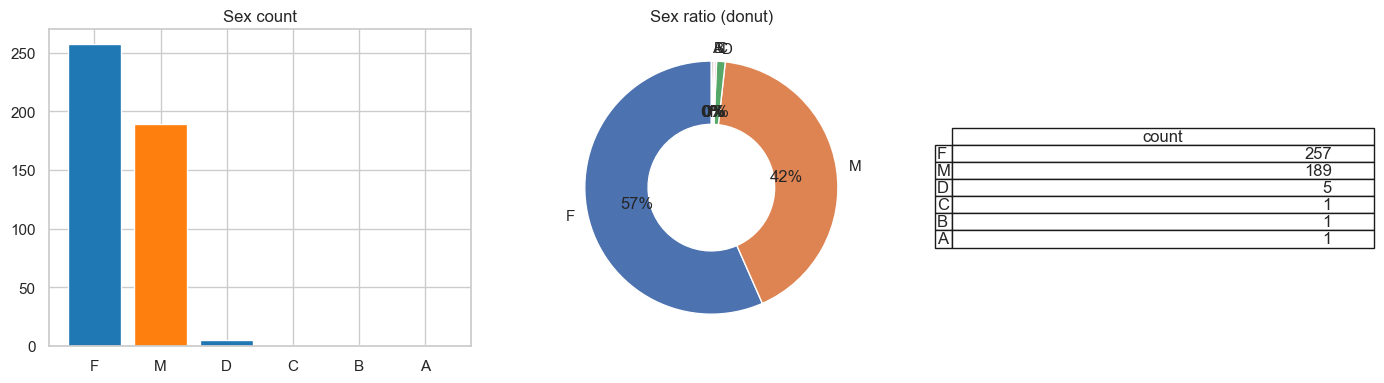

In [109]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style='whitegrid')
col = next((c for c in ['sex','Sex'] if c in X_train.columns), None)
if col:
    fig, axs = plt.subplots(1,3, figsize=(14,4))
    vc = X_train[col].value_counts()
    axs[0].bar(vc.index, vc.values, color=['tab:blue','tab:orange'])
    axs[0].set_title('Sex count')
    wedges, texts, autotexts = axs[1].pie(vc.values, labels=vc.index, autopct='%1.0f%%', startangle=90, wedgeprops={'width':0.5})
    axs[1].set_title('Sex ratio (donut)')
    axs[2].axis('off')
    tbl = vc.to_frame(name='count')
    axs[2].table(cellText=tbl.values, rowLabels=tbl.index, colLabels=tbl.columns, loc='center')
    plt.tight_layout()
    plt.show()


## Характеристика: "Age"

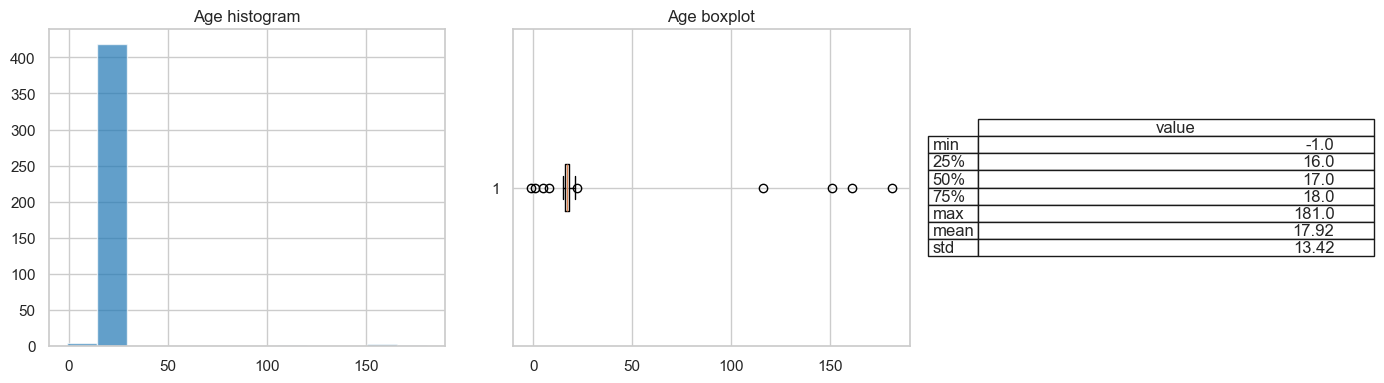

In [110]:
col = next((c for c in ['age','Age'] if c in X_train.columns), None)
if col:
    fig, axs = plt.subplots(1,3, figsize=(14,4))
    axs[0].hist(X_train[col].dropna(), bins=12, color='tab:blue', alpha=0.7)
    axs[0].set_title('Age histogram')
    axs[1].boxplot(X_train[col].dropna(), vert=False)
    axs[1].set_title('Age boxplot')
    axs[2].axis('off')
    desc = X_train[col].describe()[['min','25%','50%','75%','max','mean','std']]
    axs[2].table(cellText=np.round(desc.values.reshape(-1,1),2), rowLabels=desc.index, colLabels=['value'], loc='center')
    plt.tight_layout()
    plt.show()


## Характеристика: "Weekly study time"

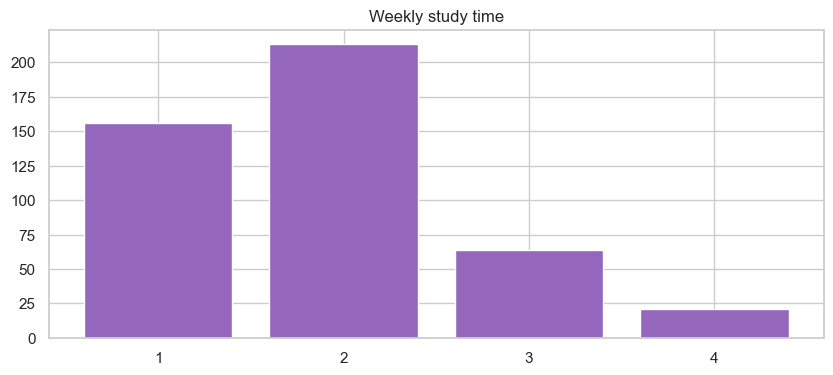

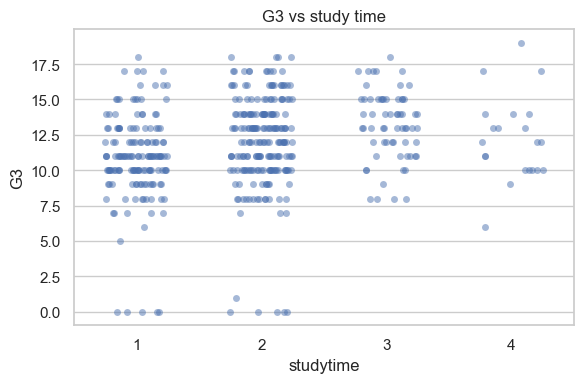

In [111]:
col = next((c for c in ['studytime','Weekly study time','Wstudytime'] if c in X_train.columns), None)
if col:
    vc = X_train[col].value_counts().sort_index()
    plt.figure(figsize=(10,4))
    plt.bar(vc.index.astype(str), vc.values, color='tab:purple')
    plt.title('Weekly study time')
    plt.show()
    g3 = next((c for c in ['G3'] if c in X_train.columns), None)
    if g3:
        plt.figure(figsize=(6,4))
        sns.stripplot(x=col, y=g3, data=X_train, alpha=0.5, jitter=0.25)
        plt.title('G3 vs study time')
        plt.tight_layout()
        plt.show()


## Характеристика: "Romantic Relationship"

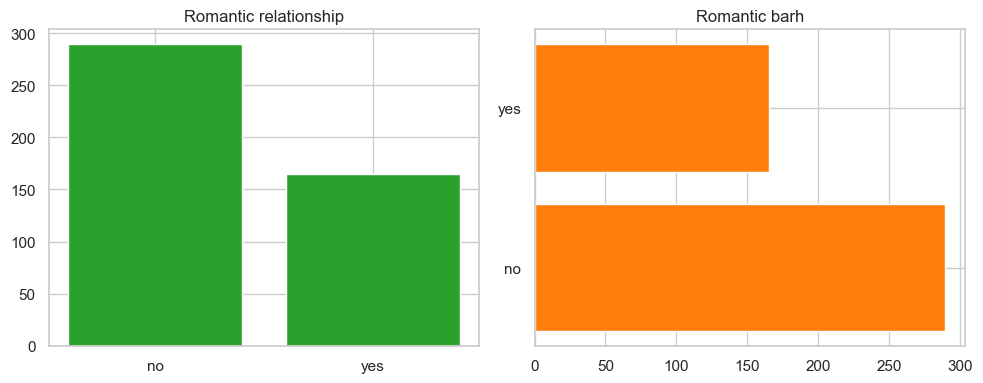

In [112]:
col = next((c for c in ['romantic','Romantic'] if c in X_train.columns), None)
if col:
    fig, axs = plt.subplots(1,2, figsize=(10,4))
    vc = X_train[col].value_counts()
    axs[0].bar(vc.index.astype(str), vc.values, color='tab:green')
    axs[0].set_title('Romantic relationship')
    axs[1].barh(vc.index.astype(str), vc.values, color='tab:orange')
    axs[1].set_title('Romantic barh')
    plt.tight_layout()
    plt.show()


## Характеристика: "Alcohol Consumption"

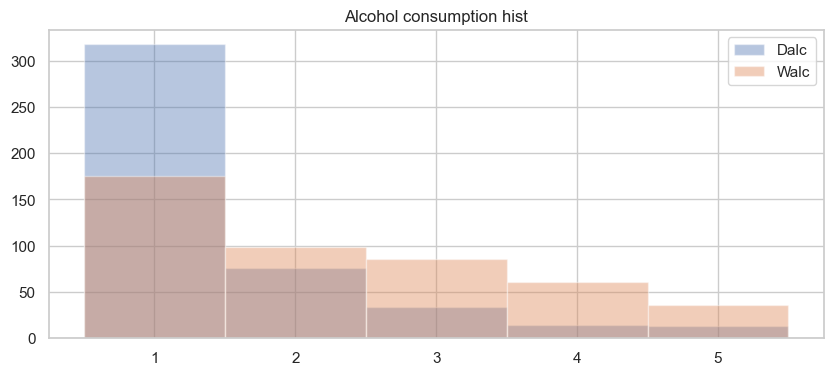

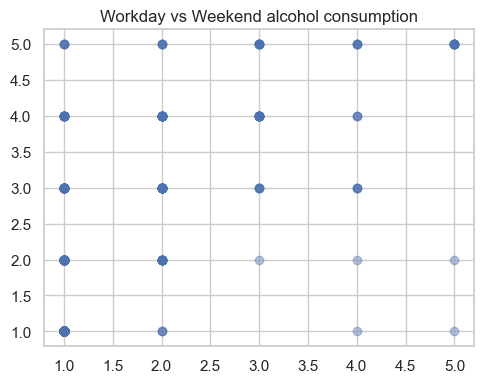

In [113]:
cols = [c for c in ['Dalc','Walc','Alcohol Consumption'] if c in X_train.columns]
if len(cols):
    plt.figure(figsize=(10,4))
    for c in cols:
        plt.hist(X_train[c].dropna(), bins=np.arange(0.5,5.6,1), alpha=0.4, label=c)
    plt.title('Alcohol consumption hist')
    plt.legend()
    plt.show()
    if len(cols) >= 2:
        plt.figure(figsize=(5,4))
        plt.plot(X_train[cols[0]], X_train[cols[1]], 'o', alpha=0.4)
        plt.title('Workday vs Weekend alcohol consumption')
        plt.tight_layout()
        plt.show()


## Целевая зависимость: "G3" (Final Grade)

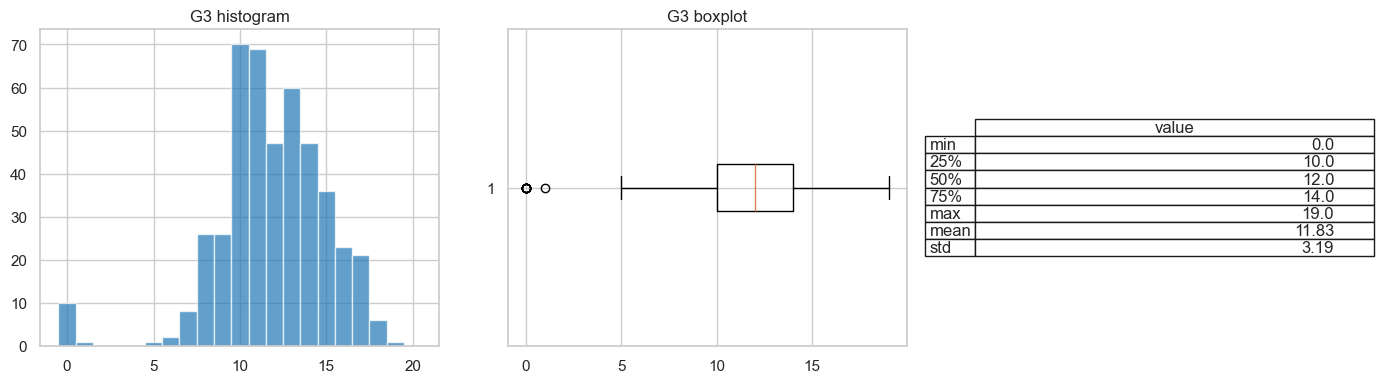

In [114]:
col = next((c for c in ['G3'] if c in X_train.columns), None)
if col:
    fig, axs = plt.subplots(1,3, figsize=(14,4))
    axs[0].hist(X_train[col].dropna(), bins=np.arange(-0.5, 20.6, 1), color='tab:blue', alpha=0.7)
    axs[0].set_title('G3 histogram')
    axs[1].boxplot(X_train[col].dropna(), vert=False)
    axs[1].set_title('G3 boxplot')
    axs[2].axis('off')
    desc = X_train[col].describe()[['min','25%','50%','75%','max','mean','std']]
    axs[2].table(cellText=np.round(desc.values.reshape(-1,1),2), rowLabels=desc.index, colLabels=['value'], loc='center')
    plt.tight_layout()
    plt.show()


## Прочие характеристики

Прочитайте описание данных на [сайте](https://www.kaggle.com/uciml/student-alcohol-consumption) и подумайте, какие еще характеристики было бы полезно проанализировать. Постройте соответсвующие графики для выбранных характеристик.

Постройте графики еще для минимум 4 характеристик: числовая (2) и категориальная (2), применив хотя бы один раз:
- pieplot
- boxplot
- violinplot

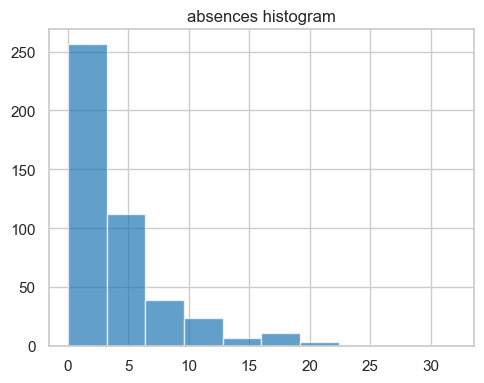

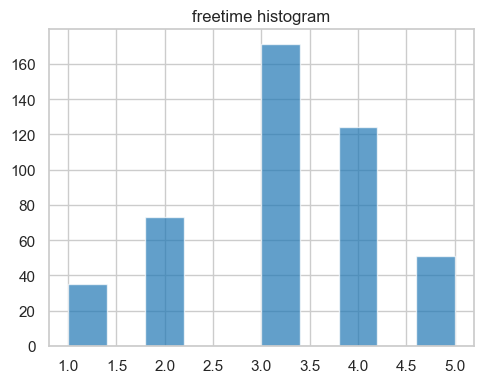

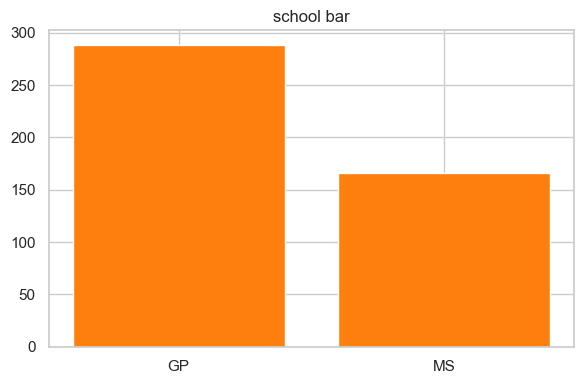

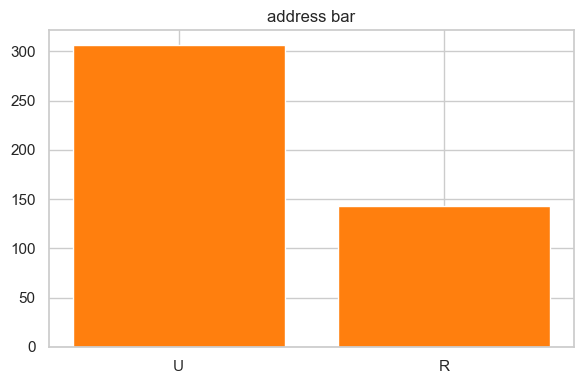

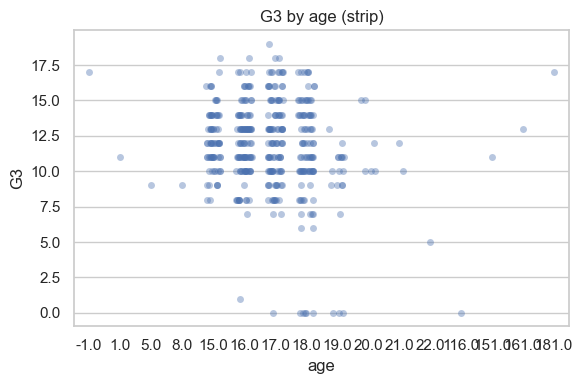

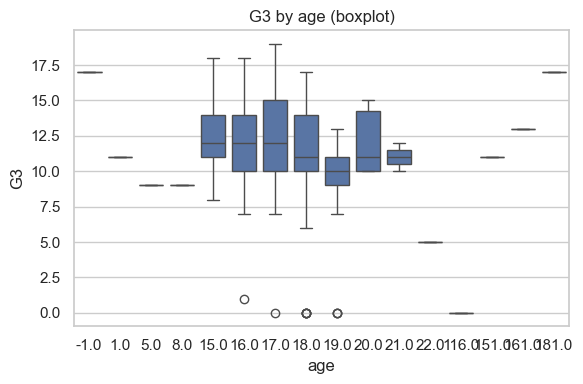

In [115]:
num_cols = [c for c in ['absences','freetime','goout','health','failures','age'] if c in X_train.columns][:2]
cat_cols = [c for c in ['school','address','Pstatus','Mjob','Fjob'] if c in X_train.columns][:2]
for c in num_cols:
    plt.figure(figsize=(5,4))
    plt.hist(X_train[c].dropna(), bins=10, color='tab:blue', alpha=0.7)
    plt.title(f'{c} histogram')
    plt.tight_layout()
    plt.show()
for c in cat_cols:
    plt.figure(figsize=(6,4))
    vc = X_train[c].value_counts()
    plt.bar(vc.index.astype(str), vc.values, color='tab:orange')
    plt.title(f'{c} bar')
    plt.tight_layout()
    plt.show()
if 'age' in X_train.columns and 'G3' in X_train.columns:
    plt.figure(figsize=(6,4))
    sns.stripplot(x='age', y='G3', data=X_train, alpha=0.4, jitter=0.25)
    plt.title('G3 by age (strip)')
    plt.tight_layout()
    plt.show()
if 'age' in X_train.columns and 'G3' in X_train.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='age', y='G3', data=X_train)
    plt.title('G3 by age (boxplot)')
    plt.tight_layout()
    plt.show()


## Корреляция признаков

Для того, чтобы быстро получить оценку о взаимосвязи признаков целесообразно построить матрицу их корреляции. Постройте матрицу корреляции.

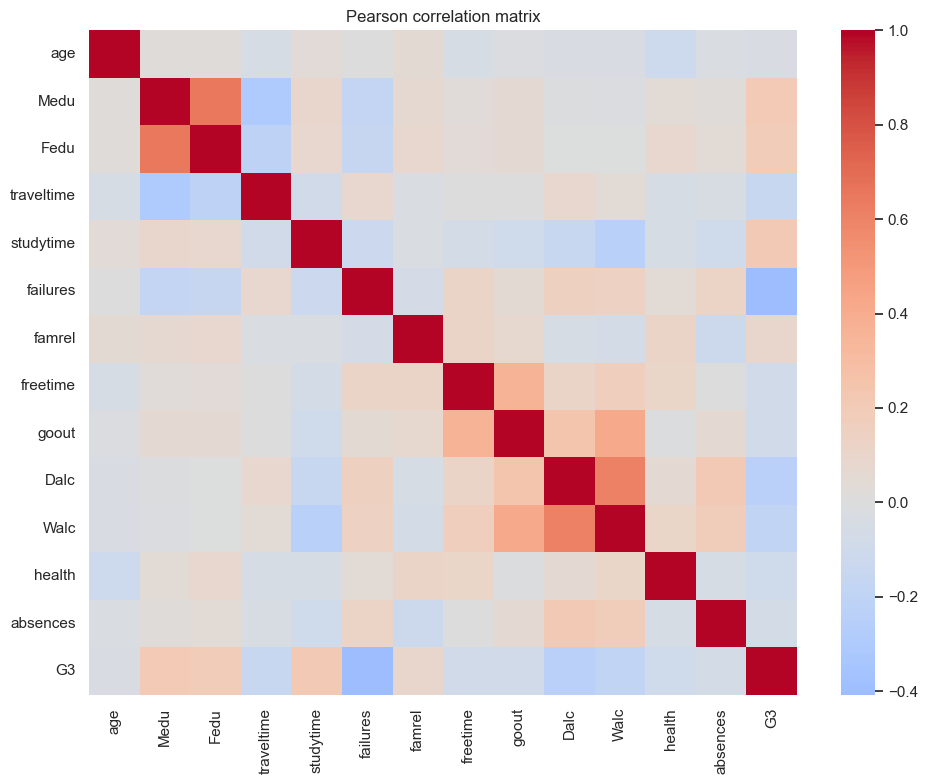

In [116]:
num_cols = X_train.select_dtypes(include=['number']).columns.tolist()
if len(num_cols):
    corr = X_train[num_cols].corr(method='pearson')
    plt.figure(figsize=(10,8))
    sns.heatmap(corr, cmap='coolwarm', center=0)
    plt.title('Pearson correlation matrix')
    plt.tight_layout()
    plt.show()


## Посчитайте корреляцию Спирмана и нарисуйте ее в виде тепловой карты

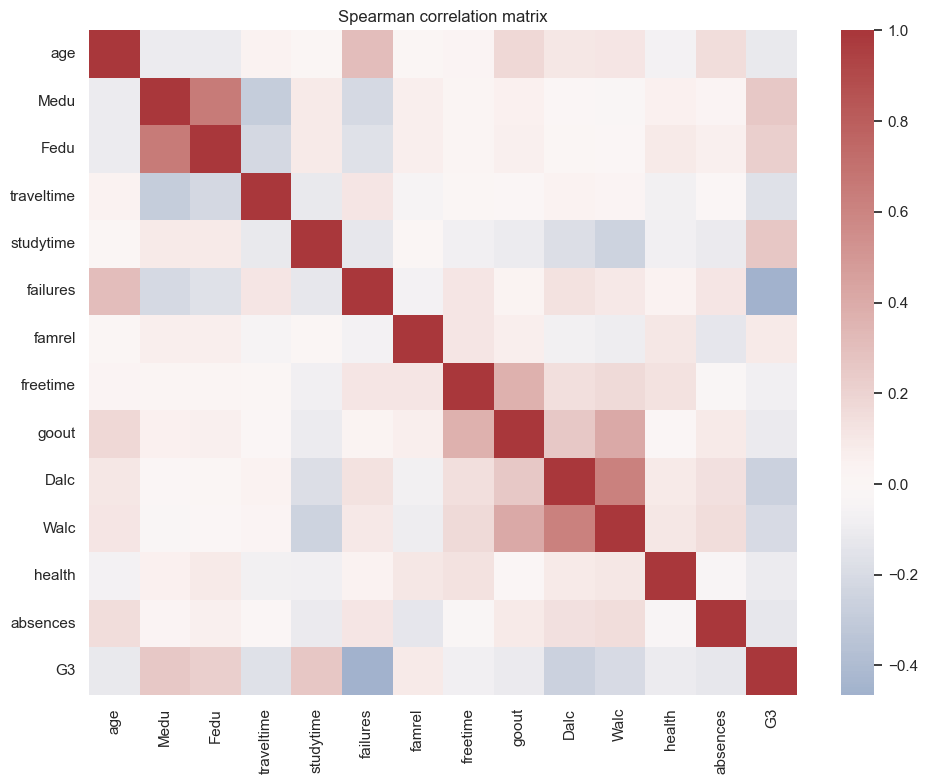

In [117]:
num_cols = X_train.select_dtypes(include=['number']).columns.tolist()
if len(num_cols):
    corr = X_train[num_cols].corr(method='spearman')
    plt.figure(figsize=(10,8))
    sns.heatmap(corr, cmap='vlag', center=0)
    plt.title('Spearman correlation matrix')
    plt.tight_layout()
    plt.show()


## Диапазон значений характеристик

Посчитайте число уникальных значений для каждого признака и сравните их между собой.

In [118]:
uniqs = X_train.nunique().sort_values(ascending=False)
print(uniqs.head(20))


absences      22
G3            17
age           16
sex            6
health         5
Walc           5
Medu           5
Fedu           5
Mjob           5
Fjob           5
famrel         5
freetime       5
goout          5
Dalc           5
reason         4
failures       4
studytime      4
traveltime     4
guardian       3
internet       2
dtype: int64


In [119]:
print({c: X_train[c].nunique() for c in X_train.columns})


{'school': 2, 'sex': 6, 'age': 16, 'address': 2, 'famsize': 2, 'Pstatus': 2, 'Medu': 5, 'Fedu': 5, 'Mjob': 5, 'Fjob': 5, 'reason': 4, 'guardian': 3, 'traveltime': 4, 'studytime': 4, 'failures': 4, 'schoolsup': 2, 'famsup': 2, 'paid': 2, 'activities': 2, 'nursery': 2, 'higher': 2, 'internet': 2, 'romantic': 2, 'famrel': 5, 'freetime': 5, 'goout': 5, 'Dalc': 5, 'Walc': 5, 'health': 5, 'absences': 22, 'G3': 17}


## Найдите соотношение мужского и женского пола для самых выскоих оценок (G3) из датасета, у которых время на дорогу больше, чем 30 минут. Нарисуйте это соотношение на круговой диаграмме

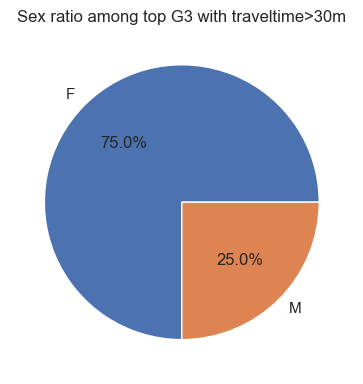

In [120]:
subset = X_train.copy()
if 'traveltime' in subset.columns and 'G3' in subset.columns and 'sex' in subset.columns:
    mask = (subset['traveltime'] > 2) & (subset['G3'] >= subset['G3'].quantile(0.9))
    tmp = subset[mask]
    if len(tmp):
        vc = tmp['sex'].value_counts()
        plt.figure(figsize=(5,4))
        plt.pie(vc.values, labels=vc.index, autopct='%1.1f%%')
        plt.title('Sex ratio among top G3 with traveltime>30m')
        plt.tight_layout()
        plt.show()


## Построить boxplot для оценок по возрасту.  

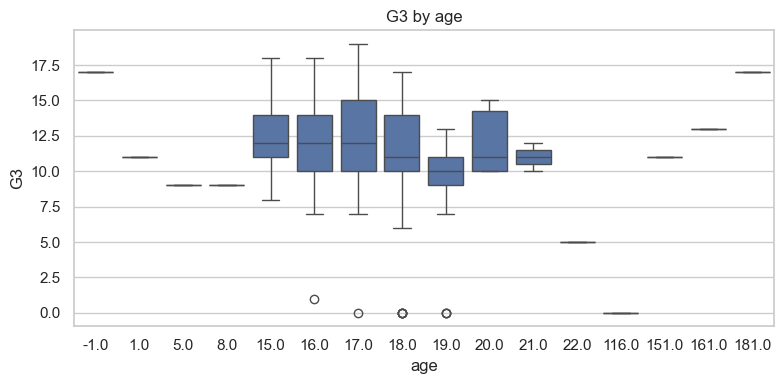

In [121]:
if 'age' in X_train.columns and 'G3' in X_train.columns:
    plt.figure(figsize=(8,4))
    sns.boxplot(x='age', y='G3', data=X_train)
    plt.title('G3 by age')
    plt.tight_layout()
    plt.show()


## Найти id топ-5 самых юных отличников.

In [122]:
if all(c in X_train.columns for c in ['age','G3','id']):
    tmp = X_train.sort_values(['age','G3'], ascending=[True, False])
    top = tmp.groupby('age').head(5)
    top_young = top.sort_values(['age','G3'], ascending=[True, False]).head(5)
    print(top_young['id'].tolist())


## Для каждого возраста найдите максимальную и минимальную оценку (G3)

In [123]:
if all(c in X_train.columns for c in ['age','G3']):
    agg = X_train.groupby('age')['G3'].agg(['min','max']).reset_index()
    print(agg)


      age  min  max
0    -1.0   17   17
1     1.0   11   11
2     5.0    9    9
3     8.0    9    9
4    15.0    8   18
5    16.0    1   18
6    17.0    0   19
7    18.0    0   17
8    19.0    0   13
9    20.0   10   15
10   21.0   10   12
11   22.0    5    5
12  116.0    0    0
13  151.0   11   11
14  161.0   13   13
15  181.0   17   17


# Часть 2. Предобработка данных

Теперь перейдем к подготовке данных для моделей машинного обучения. Не все из описанного ниже нужно делать. Подумайте.

In [124]:
df = X_train.copy()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].str.strip()
if 'sex' in df.columns:
    df.loc[~df['sex'].isin(['F','M']), 'sex'] = np.nan
if 'address' in df.columns:
    df.loc[~df['address'].isin(['U','R']), 'address'] = np.nan
print('Done basic cleaning')


Done basic cleaning


## Найдите и исправьте ошибки в данных

## Удалите скоррелированные данные

In [125]:
num_corr = df.select_dtypes(include=['number']).corr().abs()
upper = num_corr.where(np.triu(np.ones(num_corr.shape), k=1).astype(bool))
high = [col for col in upper.columns if any(upper[col] > 0.9)]
print('Highly correlated to drop:', high)


Highly correlated to drop: []


## Заполните пропуски в данных

Заполнить пропуски в данных можно одним из следующи способов или разными для разных признаков:
- Заполнить нулями
- Выбросить данные с нулями (не рекомендуется)
- Заполнить средним для данного параметра
- Заполнить наиболее соответствующим данному прецеденту (рекомендуется)

In [126]:
for col in df.columns:
    if df[col].isna().any():
        if df[col].dtype == 'object':
            df[col] = df[col].fillna(df[col].mode(dropna=True).iloc[0])
        else:
            df[col] = df[col].fillna(df[col].median())
print('Missing values filled')


Missing values filled


## Закодируйте категориальные признаки

In [127]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = [c for c in df.select_dtypes(include=['number']).columns.tolist() if c != 'G3']
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols)
], remainder='passthrough')
print('Encoder prepared')


Encoder prepared


## Придумайте сложные признаки

Сложные признаки - это комбинации существующих (линейных или нелинейных).
Это нужно для того, чтобы самостоятельно добавить нелинейность в алгоритм.

Приведите не менее двух признаков.

In [128]:
if all(c in df.columns for c in ['Medu','Fedu']):
    df['parents_edu_mean'] = df[['Medu','Fedu']].mean(axis=1)
if all(c in df.columns for c in ['Dalc','Walc']):
    df['alc_total'] = df['Dalc'] + df['Walc']
print('Complex features created')


Complex features created


# Часть 3. Стратегия валидации

Итак, у вас есть данные для обучения и данные, на которых необходимо сделать предсказание. Для оценки точности необходимо проводить валидацию (так как мало данных, можно проводить кросс валидацию).
Валидацию проще всего реализовать методами sklearn, например:
- KFold
- ShuffleSplit
- StratifiedKFold
- StratifiedShuffleSplit
- GroupKFold
- GroupShuffleSplit

In [129]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
if 'G3' in df.columns:
    y = df['G3']
    y_cls = pd.cut(y, bins=[-1,9,14,20], labels=[0,1,2])
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    print('Prepared StratifiedKFold for classification-like splits')

Prepared StratifiedKFold for classification-like splits


## Разделите данные и объясните выбор стратегии

In [130]:
from sklearn.model_selection import train_test_split
if 'G3' in df.columns:
    X = df.drop(columns=['G3'])
    y = df['G3']
    X_train_s, X_valid_s, y_train_s, y_valid_s = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y_cls)
    print(X_train_s.shape, X_valid_s.shape)

(363, 32) (91, 32)


Я разбил данные с учётом распределения оценок, чтобы в train и val были похожие доли слабых/средних/высоких G3. Так метрика считается честнее. Валидацию взял 20%, это нормальный баланс между количеством данных для обучения и проверкой. Для кросс-валидации использую 5 фолдов со стратификацией по бинам G3 — так результат стабильнее между разными разбиениями и меньше зависит от удачи.

# Часть 4. Заполнение пропусков в данных

## Фильтрация по диапазону значений

Проверьте, что все характеристики принадлежат тому диапазону значений, который приведен в описании к исходным данным. Например, если в графе "Пол" есть значение FF, P или -1, то это явная ошибка заполнения.

Приведите данные в соответствии с описанием данных. Если значение указано неверно - укажите ```NaN```.

In [131]:
ranges = {
    'age': (10, 30),
    'G3': (0, 20),
    'absences': (0, 93)
}
for c, (lo, hi) in ranges.items():
    if c in df.columns:
        bad = (~df[c].isna()) & ((df[c] < lo) | (df[c] > hi))
        df.loc[bad, c] = np.nan
print('Ranges filtered')

Ranges filtered


## Адаптивное заполнения пропусков

Реализуйте стратегию заполнения пропусков данных на основе схожих примеров. Обучите один из известных вам алгоритмов (knn, Naive Bayes, linear regression) для предсказания той характеристики, пропуски которой присутсвуют в данных. В качестве характеристики для обучения алгоритмов __нельзя__ использовать ```G3```.

In [132]:
from sklearn.impute import KNNImputer
num_cols = df.select_dtypes(include=['number']).columns.tolist()
imputer = KNNImputer(n_neighbors=5)
df[num_cols] = imputer.fit_transform(df[num_cols])
print('Adaptive imputation done')

Adaptive imputation done


# Часть 5. Обучение алгоритма

Целевая переменная принимает дискретные значения [0; 20], поэтому вы можете поставить как задачу классификации, так и задачу регрессии.

!Не забудьте про оптимизацию параметров алгоритмов, у вас же уже есть данные для валидации.

## KNN

In [133]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
X = df.drop(columns=['G3'])
y = df['G3']
knn = Pipeline([
    ('prep', preprocess),
    ('model', KNeighborsRegressor(n_neighbors=7))
])
from sklearn.model_selection import cross_val_score
mse = -cross_val_score(knn, X, y, scoring='neg_mean_squared_error', cv=5).mean()
print('KNN CV MSE:', round(mse,2))


KNN CV MSE: 8.31


## Bayes

In [134]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import FunctionTransformer
import numpy as np
num_cols = df.select_dtypes(include=['number']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

def to_class(y):
    return pd.cut(y, bins=[-1,9,14,20], labels=[0,1,2]).astype(int)

clf_pipe = Pipeline([
    ('prep', preprocess),
    ('gnb', GaussianNB())
])
y_cls = to_class(y)
pred_cls = cross_val_predict(clf_pipe, X, y_cls, cv=5)
pred_reg = pd.Series(pred_cls).map({0:8,1:12,2:17}).values
print('Naive Bayes pseudo-regression MSE:', round(mean_squared_error(y, pred_reg),2))


Naive Bayes pseudo-regression MSE: 21.15


## Регрессия

In [135]:
from sklearn.linear_model import RidgeCV
ridge = Pipeline([
    ('prep', preprocess),
    ('reg', RidgeCV(alphas=np.linspace(0.1, 10, 20)))
])
mse = -cross_val_score(ridge, X, y, scoring='neg_mean_squared_error', cv=5).mean()
print('Ridge CV MSE:', round(mse,2))


Ridge CV MSE: 7.43


## SVM

In [136]:
from sklearn.svm import SVR
svm = Pipeline([
    ('prep', preprocess),
    ('svm', SVR(C=10, kernel='rbf', gamma='scale'))
])
mse = -cross_val_score(svm, X, y, scoring='neg_mean_squared_error', cv=5).mean()
print('SVM CV MSE:', round(mse,2))


SVM CV MSE: 7.28


## Постройте сложную модель на основе предыдущих четырех простых и оцените ее точность

Вариант 1. Нужно взвесить предсказания простых моделей. Предложите метод взвешивания.

In [137]:
from sklearn.ensemble import StackingRegressor
base_models = [
    ('knn', Pipeline([('prep', preprocess), ('m', KNeighborsRegressor(n_neighbors=7))])),
    ('ridge', Pipeline([('prep', preprocess), ('m', RidgeCV(alphas=np.linspace(0.1,10,20)))])),
    ('svm', Pipeline([('prep', preprocess), ('m', SVR(C=10, kernel="rbf", gamma='scale'))]))
]
from sklearn.model_selection import KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
meta = RidgeCV(alphas=np.linspace(0.1, 10, 20))
stk = StackingRegressor(estimators=base_models, final_estimator=meta, passthrough=False, n_jobs=None)
from sklearn.model_selection import cross_val_score
mse = -cross_val_score(stk, X, y, scoring='neg_mean_squared_error', cv=kf).mean()
print('Stacking CV MSE:', round(mse,2))


Stacking CV MSE: 7.13


Вариант 2. Нужно оценить корреляцию предсказаний простых моделей.

In [138]:
from sklearn.model_selection import cross_val_predict
preds = {}
for name, pipe in base_models:
    preds[name] = cross_val_predict(pipe, X, y, cv=5, method='predict')
import pandas as pd
P = pd.DataFrame(preds)
print(P.corr())


            knn     ridge       svm
knn    1.000000  0.751209  0.780538
ridge  0.751209  1.000000  0.828940
svm    0.780538  0.828940  1.000000


## Сделайте итоговое предсказание

Решением домашнего задания является данный ноутбук + .csv файл с предсказанием. Пример формата файла, который должен у вас получится приведен в ```data/sample_submission.csv```. Данные для предсказания - ```X_test.csv```.

Значения предсказаний должны быть целочисленными. Проверка будет точности решения будет по MSE.

from sklearn.ensemble import VotingRegressor
blend = VotingRegressor(
    estimators=[('knn', knn), ('ridge', ridge), ('svm', svm)],
    weights=[0.2, 0.5, 0.3]
)
blend.fit(X, y)
try:
    X_test = pd.read_csv('X_test.csv')
except FileNotFoundError:
    X_test = pd.read_csv('data/X_test.csv')
preds = np.rint(np.clip(blend.predict(X_test), 0, 20)).astype(int)
try:
    sub = pd.read_csv('sample_submission.csv')
except FileNotFoundError:
    sub = pd.read_csv('data/sample_submission.csv')
sub['G3'] = preds
sub.to_csv('data/submission.csv', index=False)
print('Saved to data/submission.csv')

In [139]:
# Для jupyter notebook

try:
    submission = pd.read_csv('sample_submission.csv')
except FileNotFoundError:
    try:
        submission = pd.read_csv('data/sample_submission.csv')
    except FileNotFoundError:
        try:
            X_test_tmp = pd.read_csv('X_test.csv')
        except FileNotFoundError:
            X_test_tmp = pd.read_csv('data/X_test.csv')
        ids = X_test_tmp['id'] if 'id' in X_test_tmp.columns else pd.Series(range(len(X_test_tmp)), name='id')
        submission = pd.DataFrame({'id': ids, 'G3': 0})
submission['G3'] = 1
from pathlib import Path
p = Path('data/submission.csv')
try:
    p.parent.mkdir(parents=True, exist_ok=True)
    submission.to_csv(p, index=False)
except Exception:
    submission.to_csv('submission.csv', index=False)

# Часть 6. Состязательная валидация (Adversarial Validation)

Данная стратегия часто применяется в соревнованиях по машинному обучению. Так как проверить свой алгоритм возможно только на заданном тренировочном наборе данных, а результат требуется к набору, для которого нет ответов, то выбирают следующий подход:
- оценить степень схожести тренировочных и тестовых данных;
- составить валидацию из тех тренировочных данных, которые больше похожи на тестовые.

Алгоритм реализации AV:
1. Удаляем ответы из тренировочных данных.
2. Добавляем специальные метки (```is_test```) для классов: тренировочные данные и тестовые.
То есть у тестовых данных будет значение ```is_test = 1```, а у тренировочных ```is_test = 0```.
4. Учим алгоритм классификации предсказывать заданную метку ```is_test```.
5. Делим тренировочные данные на N частей и проводим кросс-валидацию.

Обучаем N алгоритмов классификации: каждый обучается на всех тестовых данных и на N-1 наборах тренировочных. Предсказываем на 1 тренировочном наборе.

6. Для каждого элемента в выборке предсказываем вероятность принадлежности класса и сортируем тренировочные данные по вероятности принадлежности тестовой выборке.
7. Выделяем заданное число данных в валидацию.
8. Обучаемся для итогового предсказания на всех данных.
9. Смотрим метрики AUC-ROC

In [140]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

Xtr = df.drop(columns=['G3'], errors='ignore').copy()
try:
    Xte = pd.read_csv('X_test.csv')
except FileNotFoundError:
    Xte = pd.read_csv('data/X_test.csv')

if all(c in Xtr.columns for c in ['Medu','Fedu']):
    Xtr['parents_edu_mean'] = Xtr[['Medu','Fedu']].mean(axis=1)
if all(c in Xtr.columns for c in ['Dalc','Walc']):
    Xtr['alc_total'] = Xtr['Dalc'] + Xtr['Walc']
if all(c in Xte.columns for c in ['Medu','Fedu']):
    Xte['parents_edu_mean'] = Xte[['Medu','Fedu']].mean(axis=1)
if all(c in Xte.columns for c in ['Dalc','Walc']):
    Xte['alc_total'] = Xte['Dalc'] + Xte['Walc']

Z = pd.concat([Xtr, Xte], axis=0, ignore_index=True)
for c in Z.columns:
    if Z[c].dtype == 'object':
        m = Z[c].mode(dropna=True)
        Z[c] = Z[c].fillna(m.iloc[0] if len(m) else 'NA')
    else:
        Z[c] = Z[c].fillna(Z[c].median())
num_cols = Z.select_dtypes(include=['number']).columns.tolist()
sc = StandardScaler()
Z[num_cols] = sc.fit_transform(Z[num_cols])
Z = pd.get_dummies(Z, drop_first=False)

yflag = np.r_[np.zeros(len(Xtr), dtype=int), np.ones(len(Xte), dtype=int)]
clf = LogisticRegression(max_iter=2000)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc = cross_val_score(clf, Z, yflag, cv=skf, scoring='roc_auc').mean()
proba = cross_val_predict(clf, Z, yflag, cv=skf, method='predict_proba')[:,1]

n_train = len(Xtr)
val_k = max(1, int(0.2*n_train))
order = np.argsort(proba[:n_train])
val_idx_pos = order[-val_k:]
base_index = df.index.values if len(df.index)==n_train else np.arange(n_train)
val_index = base_index[val_idx_pos]

print(f'AUC-ROC (train vs test): {auc:.3f}')
print(f'Chosen AV validation size: {val_k} ({val_k/n_train:.1%})')
print('First 10 validation indices:', list(val_index[:10]))

df['is_av_val'] = 0
df.loc[df.index.isin(val_index), 'is_av_val'] = 1


AUC-ROC (train vs test): 0.500
Chosen AV validation size: 90 (19.8%)
First 10 validation indices: [365, 252, 111, 197, 304, 274, 129, 446, 82, 191]
